# Evaluación del modelo clasificador de riesgo IA

En este notebook evaluamos el modelo entrenado sobre el conjunto de test.

Métricas:
1. Classification report (precision, recall, f1 por clase)
2. F1-score macro
3. Matriz de confusión
4. Curva ROC multiclase (One-vs-Rest)
5. Análisis de errores
6. Registro de métricas en MLflow

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_artificial"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ia_artificial"
functions._DATASET_TAGS = {"dataset_type": "artificial", "dataset_source": "eu_ai_act_flagged"}

## 1. Carga del modelo y datos de test

In [11]:
import pandas as pd
import joblib

modelo = joblib.load("model/modelo_baseline.joblib")
tfidf = joblib.load("model/tfidf_vectorizer.joblib")
print("Modelo baseline y vectorizador cargados correctamente.")

test_df = pd.read_csv("data/processed/test.csv")
X_test = test_df["text_final"]
y_test = test_df["etiqueta"]

print(f"Test: {len(X_test)} muestras")
print(f"Clases: {sorted(y_test.unique())}")

Modelo baseline y vectorizador cargados correctamente.
Test: 45 muestras
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Classification report y F1-score macro

In [12]:
from functions import evaluar_modelo

y_pred, report_dict = evaluar_modelo(modelo, tfidf, X_test, y_test)

TypeError: evaluar_modelo() takes 3 positional arguments but 4 were given

## 3. Matriz de confusión

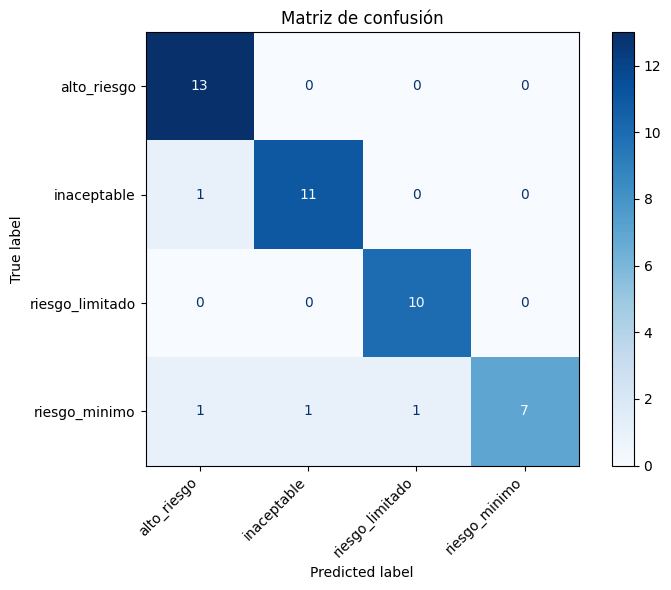

In [ ]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred, labels=clases)

## 4. Curva ROC multiclase

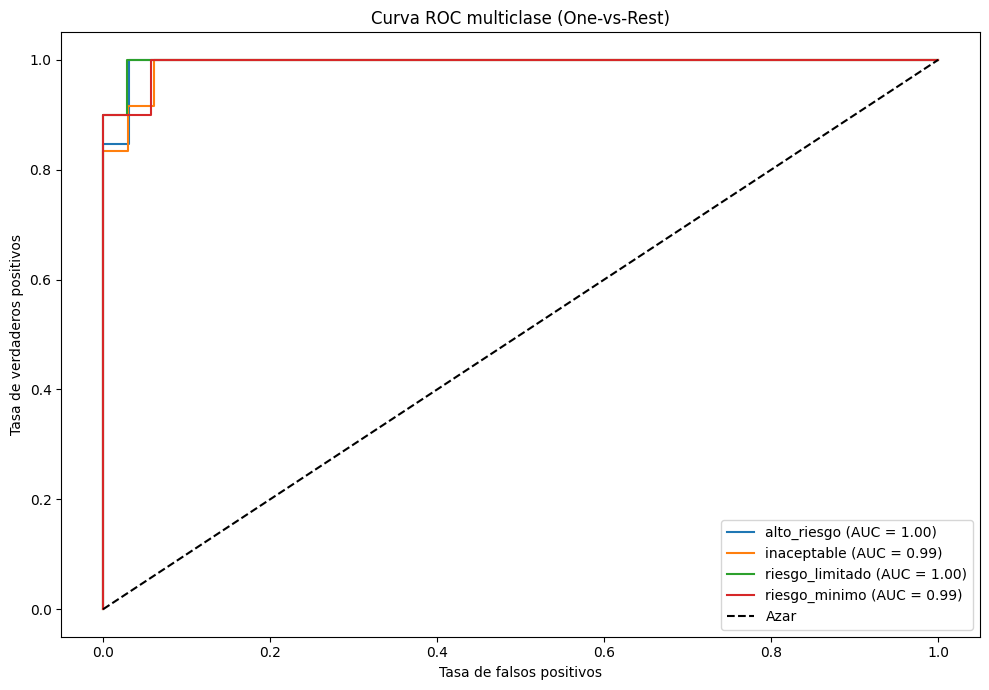


ROC AUC macro: 0.9948
  alto_riesgo: 0.9952
  inaceptable: 0.9924
  riesgo_limitado: 0.9971
  riesgo_minimo: 0.9943


In [ ]:
from functions import plot_curva_roc_multiclase

fig_roc, roc_auc_dict = plot_curva_roc_multiclase(modelo, tfidf, X_test, y_test)

## 5. Análisis de errores

In [ ]:
from functions import analisis_errores

df_errores = analisis_errores(modelo, tfidf, X_test, y_test)

Total de errores: 4 de 45 (8.9%)

Confusiones más frecuentes:
etiqueta_real  etiqueta_predicha
inaceptable    alto_riesgo          1
riesgo_minimo  alto_riesgo          1
               inaceptable          1
               riesgo_limitado      1
dtype: int64

Ejemplos mal clasificados:
  Real: riesgo_minimo | Predicho: inaceptable
  Texto: sistema reconocimiento imagen satelital monitorizar cultivo agrícola detectar zona afectado plaga sequía orientar inspec...

  Real: riesgo_minimo | Predicho: riesgo_limitado
  Texto: sistema generación automático pregunta examen tipo test docente universitario creer batería pregunta temario proporciona...

  Real: riesgo_minimo | Predicho: alto_riesgo
  Texto: algoritmo detección spam correos phishing filtrar automáticamente carpeta deseado usuario posibilidad revisión...

  Real: inaceptable | Predicho: alto_riesgo
  Texto: sistema instalado estadio fútbol identificar biométricamente asistente manifestación previo confeccionar lista compartir...



## 6. Registro de métricas en MLflow

In [ ]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import numpy as np
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", np.mean(list(roc_auc_dict.values())))

        mlflow.log_artifact("model/matriz_confusion.png")
        mlflow.log_artifact("model/curva_roc.png")

        print("✓ Métricas de test registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://34.244.146.100
⚠ MLflow no disponible: API request to https://34.244.146.100/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPSConnectionPool(host='34.244.146.100', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_ia (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate (_ssl.c:1010)')))


In [ ]:
import subprocess                                                                                                                                                                      
subprocess.run(["pip", "install", "python-dotenv"])   

CompletedProcess(args=['pip', 'install', 'python-dotenv'], returncode=0)

## 7. Conclusiones

Documentar aquí las conclusiones tras observar las métricas:
- ¿Qué clases se confunden más entre sí?
- ¿El modelo generaliza bien o muestra signos de overfitting?
- ¿Qué mejoras se podrían probar en iteraciones futuras?